In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('bina_az_yt.csv')
pd.set_option('display.max_columns', None)
data = df.copy()
data.head(3)

,Unnamed: 0,_id,url,crawl_date,title,price,price_currency,poster,poster_type,Ünvan,description,Elanın nömrəsi,Yeniləndi,Kateqoriya,Mərtəbə,Sahə,Otaq sayı,Kupça,İpoteka,locations,latitude,longitude,image_link,seher
0,0,6,https://bina.az/items/1893097,05 Fevral 2021 18:51,"Satılır 3 otaqlı yeni tikili 135 m², Gənclik m.",300000,AZN,Mubariz,vasitəçi (agent),"Bakı şəhəri, Bakıxanov küçəsi",Təcili Satılır...Qaz Kupça var..\nRoseville...,1893097,05 Fevral 2021,Yeni tikili,5 / 17,135 m²,3,var,yoxdur,\nGənclik m.\nRespublika stadionu \nNərimanov ...,40.400420,49.851554,https://bina.azstatic.com/uploads/large/2021%2...,baki
1,1,22,https://bina.az/items/1885145,05 Fevral 2021 18:51,"Satılır 3 otaqlı yeni tikili 132.5 m², Nəriman...",153000,AZN,Самир Ахмедов,vasitəçi (agent),"Bakı şəhəri, ул.Табриза 21-23",Срочно.В Наримановском р-не недалеко от 162 шк...,1885145,05 Fevral 2021,Yeni tikili,10 / 16,132.5 m²,3,yoxdur,yoxdur,\nŞərq bazarı \nNərimanov r.\n\n,40.389663,49.853717,https://bina.azstatic.com/uploads/large/2021%2...,baki
2,2,72,https://bina.az/items/1893207,05 Fevral 2021 18:50,"Satılır 2 otaqlı yeni tikili 115 m², Bayıl q.",171300,AZN,Fikrət,vasitəçi (agent),"Bakı şəhəri, Q.Abbasov küçəsi","Səbail rayonu ,Bayıl qəsəbəsi Q.Abbasov küçəsi...",1893207,05 Fevral 2021,Yeni tikili,7 / 14,115 m²,2,yoxdur,yoxdur,\nSəbail r.\nBayıl q.\n\n,40.347625,49.836685,https://bina.azstatic.com/uploads/large/2021%2...,baki


In [2]:
data.nunique()

Unnamed: 0        69315
_id               69315
url               69315
crawl_date         4941
title             14475
price              2541
price_currency        1
poster             3907
poster_type           2
Ünvan             20049
description       60424
Elanın nömrəsi    69315
Yeniləndi           178
Kateqoriya            1
Mərtəbə             461
Sahə               1827
Otaq sayı            20
Kupça                 2
İpoteka               2
locations          2527
latitude          50679
longitude         48661
image_link        69315
seher                 3
dtype: int64

In [3]:
# As can be seen from the code above, there is one category and price_currency which are meaningless data to store
# Additionally, unnamed 0 columns is a set of ids which can be removed from dataset

# print(data['seher'].unique())
# print(data[])
# print(data.nunique().values)
# print(data.nunique().keys())

# let's check poster_type, kupca, ipoteka and city
for i in np.array(data.columns):
    if data[i].unique().size <= 5:
        print(f'{i} -> {data[i].unique()}')

price_currency -> ['AZN']
poster_type -> ['vasitəçi (agent)' 'mülkiyyətçi']
Kateqoriya -> ['Yeni tikili']
Kupça -> ['var' 'yoxdur' nan]
İpoteka -> ['yoxdur' 'var']
seher -> ['baki' 'xirdalan' 'sumqayit']


In [4]:
df2 = data.copy()
print(df2.columns)
print("--------------------------------------------")
empty = ['Unnamed: 0', '_id']
for i in np.array(df2.columns):
    if df2[i].unique().size == 1:
        empty.append(i)
        
df2.drop(columns=empty, inplace=True)
df2.head()

Index(['Unnamed: 0', '_id', 'url', 'crawl_date', 'title', 'price',
       'price_currency', 'poster', 'poster_type', 'Ünvan', 'description',
       'Elanın nömrəsi', 'Yeniləndi', 'Kateqoriya', 'Mərtəbə', 'Sahə',
       'Otaq sayı', 'Kupça', 'İpoteka', 'locations', 'latitude', 'longitude',
       'image_link', 'seher'],
      dtype='object')
--------------------------------------------


,url,crawl_date,title,price,poster,poster_type,Ünvan,description,Elanın nömrəsi,Yeniləndi,Mərtəbə,Sahə,Otaq sayı,Kupça,İpoteka,locations,latitude,longitude,image_link,seher
0,https://bina.az/items/1893097,05 Fevral 2021 18:51,"Satılır 3 otaqlı yeni tikili 135 m², Gənclik m.",300000,Mubariz,vasitəçi (agent),"Bakı şəhəri, Bakıxanov küçəsi",Təcili Satılır...Qaz Kupça var..\nRoseville...,1893097,05 Fevral 2021,5 / 17,135 m²,3,var,yoxdur,\nGənclik m.\nRespublika stadionu \nNərimanov ...,40.400420,49.851554,https://bina.azstatic.com/uploads/large/2021%2...,baki
1,https://bina.az/items/1885145,05 Fevral 2021 18:51,"Satılır 3 otaqlı yeni tikili 132.5 m², Nəriman...",153000,Самир Ахмедов,vasitəçi (agent),"Bakı şəhəri, ул.Табриза 21-23",Срочно.В Наримановском р-не недалеко от 162 шк...,1885145,05 Fevral 2021,10 / 16,132.5 m²,3,yoxdur,yoxdur,\nŞərq bazarı \nNərimanov r.\n\n,40.389663,49.853717,https://bina.azstatic.com/uploads/large/2021%2...,baki
2,https://bina.az/items/1893207,05 Fevral 2021 18:50,"Satılır 2 otaqlı yeni tikili 115 m², Bayıl q.",171300,Fikrət,vasitəçi (agent),"Bakı şəhəri, Q.Abbasov küçəsi","Səbail rayonu ,Bayıl qəsəbəsi Q.Abbasov küçəsi...",1893207,05 Fevral 2021,7 / 14,115 m²,2,yoxdur,yoxdur,\nSəbail r.\nBayıl q.\n\n,40.347625,49.836685,https://bina.azstatic.com/uploads/large/2021%2...,baki
3,https://bina.az/items/1893213,05 Fevral 2021 18:50,"Satılır 2 otaqlı yeni tikili 43 m², Masazır q.",44500,QASIM,vasitəçi (agent),"Bakı şəhəri, İstiqlaliyyət 14","Masazır qəsəbəsi, Yeni Bakı yaşayış kompleksi ...",1893213,05 Fevral 2021,4 / 8,43 m²,2,var,yoxdur,\nAbşeron r.\nMasazır q.\n\n,40.492294,49.747231,https://bina.azstatic.com/uploads/large/2021%2...,baki
4,https://bina.az/items/1893237,05 Fevral 2021 18:49,"Satılır 2 otaqlı yeni tikili 65 m², Memar Əcəm...",89900,Heydər bəy,vasitəçi (agent),"Bakı şəhəri, Mir Cəlal küç.","Tecili satilir !!\n4 cu mikrorayonda, Elmed kl...",1893237,05 Fevral 2021,12 / 18,65 m²,2,var,yoxdur,\nMemar Əcəmi m.\nNəsimi r.\n4-cü mikrorayon q...,40.417271,49.810311,https://bina.azstatic.com/uploads/large/2021%2...,baki


In [5]:
# Converting 'area' column from string into float 
df3 = df2.copy()
df3['Sahə'] = df3.apply(lambda x : x['Sahə'].split()[0], axis=1).astype(float)
df3.head(3)

,url,crawl_date,title,price,poster,poster_type,Ünvan,description,Elanın nömrəsi,Yeniləndi,Mərtəbə,Sahə,Otaq sayı,Kupça,İpoteka,locations,latitude,longitude,image_link,seher
0,https://bina.az/items/1893097,05 Fevral 2021 18:51,"Satılır 3 otaqlı yeni tikili 135 m², Gənclik m.",300000,Mubariz,vasitəçi (agent),"Bakı şəhəri, Bakıxanov küçəsi",Təcili Satılır...Qaz Kupça var..\nRoseville...,1893097,05 Fevral 2021,5 / 17,135.0,3,var,yoxdur,\nGənclik m.\nRespublika stadionu \nNərimanov ...,40.400420,49.851554,https://bina.azstatic.com/uploads/large/2021%2...,baki
1,https://bina.az/items/1885145,05 Fevral 2021 18:51,"Satılır 3 otaqlı yeni tikili 132.5 m², Nəriman...",153000,Самир Ахмедов,vasitəçi (agent),"Bakı şəhəri, ул.Табриза 21-23",Срочно.В Наримановском р-не недалеко от 162 шк...,1885145,05 Fevral 2021,10 / 16,132.5,3,yoxdur,yoxdur,\nŞərq bazarı \nNərimanov r.\n\n,40.389663,49.853717,https://bina.azstatic.com/uploads/large/2021%2...,baki
2,https://bina.az/items/1893207,05 Fevral 2021 18:50,"Satılır 2 otaqlı yeni tikili 115 m², Bayıl q.",171300,Fikrət,vasitəçi (agent),"Bakı şəhəri, Q.Abbasov küçəsi","Səbail rayonu ,Bayıl qəsəbəsi Q.Abbasov küçəsi...",1893207,05 Fevral 2021,7 / 14,115.0,2,yoxdur,yoxdur,\nSəbail r.\nBayıl q.\n\n,40.347625,49.836685,https://bina.azstatic.com/uploads/large/2021%2...,baki


In [6]:
df4 = df3.copy()
renaming = {'Mərtəbə':'Floor','Elanın nömrəsi':'Announcement id','Sahə':'Area','Otaq sayı':'Room count','Kupça':'Kupca'}
df4.rename(columns = renaming, inplace = True)
df4.head(3)

,url,crawl_date,title,price,poster,poster_type,Ünvan,description,Announcement id,Yeniləndi,Floor,Area,Room count,Kupca,İpoteka,locations,latitude,longitude,image_link,seher
0,https://bina.az/items/1893097,05 Fevral 2021 18:51,"Satılır 3 otaqlı yeni tikili 135 m², Gənclik m.",300000,Mubariz,vasitəçi (agent),"Bakı şəhəri, Bakıxanov küçəsi",Təcili Satılır...Qaz Kupça var..\nRoseville...,1893097,05 Fevral 2021,5 / 17,135.0,3,var,yoxdur,\nGənclik m.\nRespublika stadionu \nNərimanov ...,40.400420,49.851554,https://bina.azstatic.com/uploads/large/2021%2...,baki
1,https://bina.az/items/1885145,05 Fevral 2021 18:51,"Satılır 3 otaqlı yeni tikili 132.5 m², Nəriman...",153000,Самир Ахмедов,vasitəçi (agent),"Bakı şəhəri, ул.Табриза 21-23",Срочно.В Наримановском р-не недалеко от 162 шк...,1885145,05 Fevral 2021,10 / 16,132.5,3,yoxdur,yoxdur,\nŞərq bazarı \nNərimanov r.\n\n,40.389663,49.853717,https://bina.azstatic.com/uploads/large/2021%2...,baki
2,https://bina.az/items/1893207,05 Fevral 2021 18:50,"Satılır 2 otaqlı yeni tikili 115 m², Bayıl q.",171300,Fikrət,vasitəçi (agent),"Bakı şəhəri, Q.Abbasov küçəsi","Səbail rayonu ,Bayıl qəsəbəsi Q.Abbasov küçəsi...",1893207,05 Fevral 2021,7 / 14,115.0,2,yoxdur,yoxdur,\nSəbail r.\nBayıl q.\n\n,40.347625,49.836685,https://bina.azstatic.com/uploads/large/2021%2...,baki


In [7]:
print(df4.isnull().any())
print("--------------------------------------")
print(df4.isnull().sum())

url                False
crawl_date         False
title              False
price              False
poster             False
poster_type        False
Ünvan              False
description         True
Announcement id    False
Yeniləndi          False
Floor              False
Area               False
Room count         False
Kupca               True
İpoteka            False
locations          False
latitude           False
longitude          False
image_link         False
seher              False
dtype: bool
--------------------------------------
url                  0
crawl_date           0
title                0
price                0
poster               0
poster_type          0
Ünvan                0
description        123
Announcement id      0
Yeniləndi            0
Floor                0
Area                 0
Room count           0
Kupca                1
İpoteka              0
locations            0
latitude             0
longitude            0
image_link           0
seher       

In [8]:
df5 = df4.copy()
df5['Kupca'].fillna('yoxdur', inplace=True)
print(df5.isnull().any())
print("--------------------------------")
print(df5.shape)

url                False
crawl_date         False
title              False
price              False
poster             False
poster_type        False
Ünvan              False
description         True
Announcement id    False
Yeniləndi          False
Floor              False
Area               False
Room count         False
Kupca              False
İpoteka            False
locations          False
latitude           False
longitude          False
image_link         False
seher              False
dtype: bool
--------------------------------
(69315, 20)


In [9]:
df4.head(3)

,url,crawl_date,title,price,poster,poster_type,Ünvan,description,Announcement id,Yeniləndi,Floor,Area,Room count,Kupca,İpoteka,locations,latitude,longitude,image_link,seher
0,https://bina.az/items/1893097,05 Fevral 2021 18:51,"Satılır 3 otaqlı yeni tikili 135 m², Gənclik m.",300000,Mubariz,vasitəçi (agent),"Bakı şəhəri, Bakıxanov küçəsi",Təcili Satılır...Qaz Kupça var..\nRoseville...,1893097,05 Fevral 2021,5 / 17,135.0,3,var,yoxdur,\nGənclik m.\nRespublika stadionu \nNərimanov ...,40.400420,49.851554,https://bina.azstatic.com/uploads/large/2021%2...,baki
1,https://bina.az/items/1885145,05 Fevral 2021 18:51,"Satılır 3 otaqlı yeni tikili 132.5 m², Nəriman...",153000,Самир Ахмедов,vasitəçi (agent),"Bakı şəhəri, ул.Табриза 21-23",Срочно.В Наримановском р-не недалеко от 162 шк...,1885145,05 Fevral 2021,10 / 16,132.5,3,yoxdur,yoxdur,\nŞərq bazarı \nNərimanov r.\n\n,40.389663,49.853717,https://bina.azstatic.com/uploads/large/2021%2...,baki
2,https://bina.az/items/1893207,05 Fevral 2021 18:50,"Satılır 2 otaqlı yeni tikili 115 m², Bayıl q.",171300,Fikrət,vasitəçi (agent),"Bakı şəhəri, Q.Abbasov küçəsi","Səbail rayonu ,Bayıl qəsəbəsi Q.Abbasov küçəsi...",1893207,05 Fevral 2021,7 / 14,115.0,2,yoxdur,yoxdur,\nSəbail r.\nBayıl q.\n\n,40.347625,49.836685,https://bina.azstatic.com/uploads/large/2021%2...,baki


Previous shape:  (69315, 20)
Current shape:  (66468, 20)


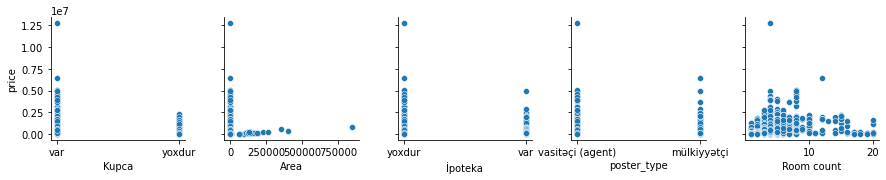

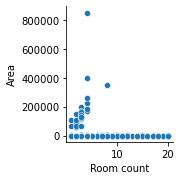

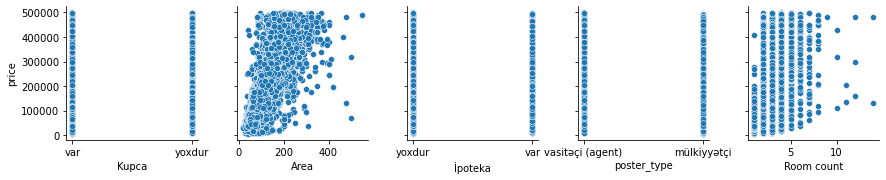

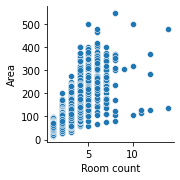

In [10]:
print('Previous shape: ', df4.shape)
df5 = df4.copy()
sns.pairplot(df5,y_vars=['price'], x_vars=['Kupca','Area','İpoteka','poster_type','Room count'])
sns.pairplot(df5,y_vars=['Area'], x_vars=['Room count'])

df5 = df5.drop(df5[(df5['Area'] >= 600) | (df5['price'] >= 500000) | (df5['price']/df5['Area'] < 100)].index)
df5 = df5.drop(df5[(df5['Room count'] >= 15) | (df5['Area']/df5['Room count'] < 9.5) | (df5['Area']/df5['Room count'] > 100)].index)

sns.pairplot(df5,y_vars=['price'], x_vars=['Kupca','Area','İpoteka','poster_type','Room count'])
sns.pairplot(df5,y_vars=['Area'], x_vars=['Room count'])
print('Current shape: ', df5.shape)

Int64Index([], dtype='int64')
Int64Index([28491, 34938, 64706], dtype='int64')
(69315, 20)
(66465, 20)


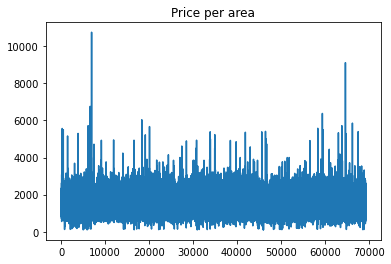

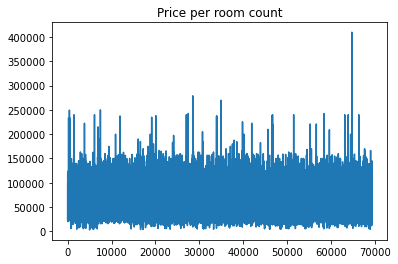

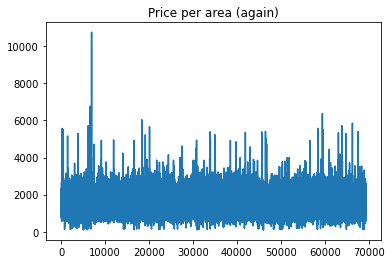

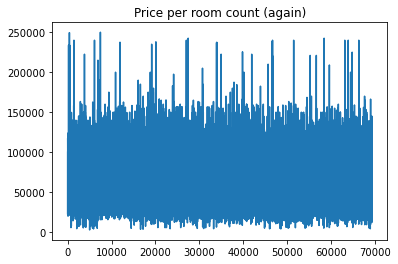

In [11]:
df_help = df4.copy()

plt.plot(df5['price']/df5['Area'])
plt.title('Price per area')  # 1
plt.figure()
plt.plot(df5['price']/df5['Room count'])
plt.title('Price per room count')
plt.figure()
print(df5[df5['price']/df5['Area'] > 300000].index) # 2
print(df5[df5['price']/df5['Room count'] > 250000].index)

print(df_help.shape)
df5 = df5.drop(df5[df5['price']/df5['Area'] > 300000].index)  # Corresponds 1
df5 = df5.drop(df5[df5['price']/df5['Room count'] > 250000].index)  # Corresponds 2


plt.plot(df5['price']/df5['Area'])
plt.title('Price per area (again)')  # 1
plt.figure()
plt.plot(df5['price']/df5['Room count'])
plt.title('Price per room count (again)')
print(df5.shape)

In [12]:
pd.set_option('display.max_rows', None)
df5['poster'].value_counts()

Anar                                                 828
Ceyhun                                               702
Orxan                                                688
Kamran                                               651
Natiq                                                619
Əli                                                  592
Ruslan                                               576
Ilqar Məmmədov                                       533
Samir                                                501
Elnur                                                486
Sarxan                                               454
Tural                                                449
Elçin                                                432
Murad                                                416
Fuad                                                 414
Orxan Allahverdiyev                                  402
Vuqar                                                376
Xatirin                        

In [13]:
chosen = df5[df['poster'] == 'Anar']
print((chosen['price']/chosen['Room count']).min())
print((chosen['price']/chosen['Room count']).max())
print((chosen['price']/chosen['Room count']).mean())

11000.0
240000.0
55443.50372383256


C:\Users\99450\AppData\Local\Temp\ipykernel_11708\582980376.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  chosen = df5[df['poster'] == 'Anar']


In [14]:
df5.corr()

,price,Announcement id,Area,Room count,latitude,longitude
price,1.000000,-0.061601,0.805308,0.650486,-0.039406,-0.000662
Announcement id,-0.061601,1.000000,-0.050964,-0.029393,0.000537,0.004384
Area,0.805308,-0.050964,1.000000,0.804201,-0.023375,-0.000269
Room count,0.650486,-0.029393,0.804201,1.000000,-0.014012,0.000876
latitude,-0.039406,0.000537,-0.023375,-0.014012,1.000000,-0.987190
longitude,-0.000662,0.004384,-0.000269,0.000876,-0.987190,1.000000


In [15]:
# Correlation with area is very low
# We can work on room count and find other ways for correlation
# Let's check on the model 
# In order to check on the model, we should keep only columns with numeric values
df6 = df5.copy()
lst_values = ['price','Announcement id','Area','Room count','latitude','longitude']
model_data = df6[lst_values]

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

X = model_data.drop(columns=['price',])
Y = model_data['price']
seed = 7
test_size = 20000
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=test_size, random_state=seed)

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
print(f'RMSE_lr: {int(rmse_lr)}     MAE_lr: {int(mae_lr)}')

RMSE_lr: 73498     MAE_lr: 37835


In [16]:
!pip install xgboost

In [17]:
from xgboost import XGBRegressor
model_xgb = XGBRegressor()

model_xgb.fit(X_train, y_train,
              eval_set=[(X_train, y_train), (X_test, y_test)],
              eval_metric=["rmse"],
              verbose=True)

y_pred_xgb = model_xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
print(f'RMSE_xgb: {int(rmse_xgb)}     MAE_xgb: {int(mae_xgb)}')

[0]	validation_0-rmse:135772.17697	validation_1-rmse:138316.29368
[1]	validation_0-rmse:99373.24439	validation_1-rmse:101518.15120
[2]	validation_0-rmse:75041.59128	validation_1-rmse:77010.16468
[3]	validation_0-rmse:59257.29131	validation_1-rmse:61078.62196
[4]	validation_0-rmse:49491.49098	validation_1-rmse:51262.56697


C:\Users\99450\anaconda3\lib\site-packages\xgboost\sklearn.py:793: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(


[5]	validation_0-rmse:43693.17895	validation_1-rmse:45447.77708
[6]	validation_0-rmse:40301.94079	validation_1-rmse:42108.65415
[7]	validation_0-rmse:38269.38005	validation_1-rmse:40055.08648
[8]	validation_0-rmse:37219.43501	validation_1-rmse:38978.42892
[9]	validation_0-rmse:36502.57214	validation_1-rmse:38265.75097
[10]	validation_0-rmse:36146.11226	validation_1-rmse:37970.22994
[11]	validation_0-rmse:35850.49180	validation_1-rmse:37719.06090
[12]	validation_0-rmse:35653.21592	validation_1-rmse:37547.15810
[13]	validation_0-rmse:35331.62449	validation_1-rmse:37253.02937
[14]	validation_0-rmse:35216.27047	validation_1-rmse:37204.50690
[15]	validation_0-rmse:34820.87061	validation_1-rmse:36841.68616
[16]	validation_0-rmse:34744.83326	validation_1-rmse:36833.63821
[17]	validation_0-rmse:34676.88797	validation_1-rmse:36810.01894
[18]	validation_0-rmse:34455.52603	validation_1-rmse:36578.49683
[19]	validation_0-rmse:34248.08201	validation_1-rmse:36432.27647
[20]	validation_0-rmse:34211.2

In [18]:
df4.head(3)
tecili = df4[df4['description'].str.contains('Təcili') == True]
tecili.shape

(4678, 20)

In [19]:
!pip install folium==0.1.5 

In [20]:
import folium

print(df5['seher'].value_counts())

# data_locations = {'xirdalan':[40.4529,49.7333], 
#                   'baki':[40.3798, 49.8486],
#                   'sumqayit':[40.5855, 49.6317]}

data_locations = {'baki':[40.39506,49.85139], 
                  'xirdalan':[40.45542, 49.7391],
                  'sumqayit':[40.57958, 49.67875]}

m = folium.Map(location=[40.3798, 49.8486], zoom_start=15)
m.simple_marker(location=[40.3798, 49.8486], popup="28 May")
m.create_map(path='mtrainier.html')

baki        63352
xirdalan     2719
sumqayit      394
Name: seher, dtype: int64


In [21]:
df5.head(3)

,url,crawl_date,title,price,poster,poster_type,Ünvan,description,Announcement id,Yeniləndi,Floor,Area,Room count,Kupca,İpoteka,locations,latitude,longitude,image_link,seher
0,https://bina.az/items/1893097,05 Fevral 2021 18:51,"Satılır 3 otaqlı yeni tikili 135 m², Gənclik m.",300000,Mubariz,vasitəçi (agent),"Bakı şəhəri, Bakıxanov küçəsi",Təcili Satılır...Qaz Kupça var..\nRoseville...,1893097,05 Fevral 2021,5 / 17,135.0,3,var,yoxdur,\nGənclik m.\nRespublika stadionu \nNərimanov ...,40.400420,49.851554,https://bina.azstatic.com/uploads/large/2021%2...,baki
1,https://bina.az/items/1885145,05 Fevral 2021 18:51,"Satılır 3 otaqlı yeni tikili 132.5 m², Nəriman...",153000,Самир Ахмедов,vasitəçi (agent),"Bakı şəhəri, ул.Табриза 21-23",Срочно.В Наримановском р-не недалеко от 162 шк...,1885145,05 Fevral 2021,10 / 16,132.5,3,yoxdur,yoxdur,\nŞərq bazarı \nNərimanov r.\n\n,40.389663,49.853717,https://bina.azstatic.com/uploads/large/2021%2...,baki
2,https://bina.az/items/1893207,05 Fevral 2021 18:50,"Satılır 2 otaqlı yeni tikili 115 m², Bayıl q.",171300,Fikrət,vasitəçi (agent),"Bakı şəhəri, Q.Abbasov küçəsi","Səbail rayonu ,Bayıl qəsəbəsi Q.Abbasov küçəsi...",1893207,05 Fevral 2021,7 / 14,115.0,2,yoxdur,yoxdur,\nSəbail r.\nBayıl q.\n\n,40.347625,49.836685,https://bina.azstatic.com/uploads/large/2021%2...,baki


49.848186320927866
40.39606936595377
49.73912230800651
40.455423940776775
49.67876572332424
40.57952236875184
89.4644689325596


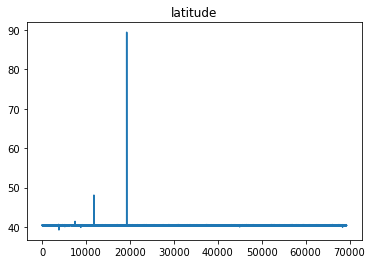

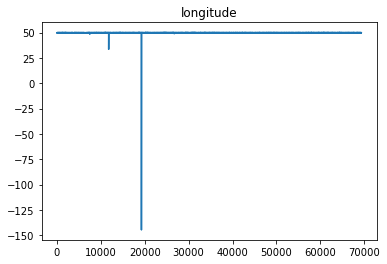

In [22]:
d = df5.copy()

# N - latitude (1)
# E - longitude (2)
center_locations = []
for i in d['seher']:
    center_locations.append(data_locations[i])

d = d.assign(city_center=center_locations)

def get_distance(x1,x2, city_center):
    return np.sqrt((city_center[0] - x1)**2 + (city_center[1] - x2)**2)
    
d['distance'] = d.apply(lambda x: get_distance(x['latitude'], x['longitude'], x['city_center']), axis=1)


plt.plot(d['latitude'])
plt.title('latitude')
plt.figure()
plt.plot(d['longitude'])
plt.title('longitude')

print(d[d['seher'] == 'baki']['longitude'].mean())
print(d[d['seher'] == 'baki']['latitude'].mean())
print(d[d['seher'] == 'xirdalan']['longitude'].mean())
print(d[d['seher'] == 'xirdalan']['latitude'].mean())
print(d[d['seher'] == 'sumqayit']['longitude'].mean())
print(d[d['seher'] == 'sumqayit']['latitude'].mean())

d.corr()
print(d['latitude'].max())

69315
66040


Text(0.5, 1.0, 'longitude')

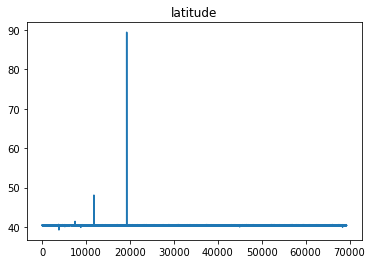

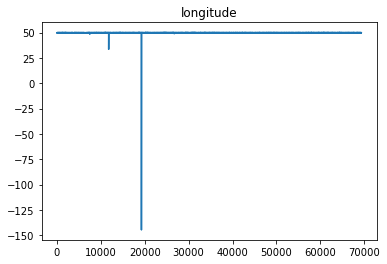

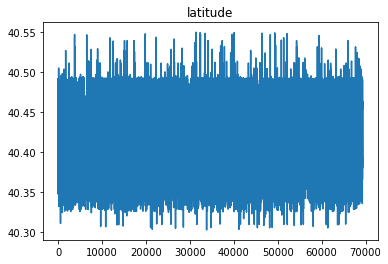

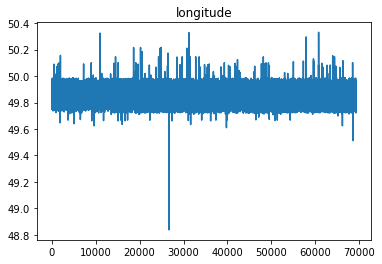

In [23]:
print(data.shape[0])

plt.plot(d['latitude'])
plt.title('latitude')
plt.figure()
plt.plot(d['longitude'])
plt.title('longitude')

d = d.drop(d[(d['latitude']>40.55) | (d['latitude']<40.3)].index)
d = d.drop(d[(d['longitude']<49.6) | d['longitude']>50.05].index)

plt.figure()
print(d.shape[0])
plt.plot(d['latitude'])
plt.title('latitude')
plt.figure()
plt.plot(d['longitude'])
plt.title('longitude')

69315
66039


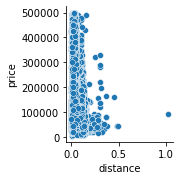

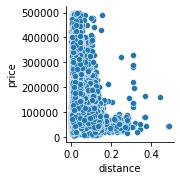

In [24]:
sns.pairplot(d,y_vars=['price'], x_vars=['distance'])
print(data.shape[0])
d = d.drop(d[d['distance'] > 0.5].index)
sns.pairplot(d,y_vars=['price'], x_vars=['distance'])
print(d.shape[0])

In [25]:
d.corr()

,price,Announcement id,Area,Room count,latitude,longitude,distance
price,1.000000,-0.061709,0.806109,0.651801,-0.305983,0.033464,-0.375815
Announcement id,-0.061709,1.000000,-0.051198,-0.029890,0.025088,0.022011,0.013072
Area,0.806109,-0.051198,1.000000,0.804659,-0.191508,0.041297,-0.234283
Room count,0.651801,-0.029890,0.804659,1.000000,-0.107794,0.025709,-0.117968
latitude,-0.305983,0.025088,-0.191508,-0.107794,1.000000,-0.367188,0.033449
longitude,0.033464,0.022011,0.041297,0.025709,-0.367188,1.000000,0.446597
distance,-0.375815,0.013072,-0.234283,-0.117968,0.033449,0.446597,1.000000


In [26]:
lst_values = ['price','Area','Room count','latitude','longitude','distance']
model_data2 = d[lst_values]

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

X = model_data2.drop(columns=['price',])
Y = model_data2['price']
seed = 7
test_size = 20000
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=test_size, random_state=seed)

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
print(f'RMSE_lr: {int(rmse_lr)}     MAE_lr: {int(mae_lr)}')

RMSE_lr: 47637     MAE_lr: 34054


In [27]:
from xgboost import XGBRegressor
model_xgb = XGBRegressor()

model_xgb.fit(X_train, y_train,
              eval_set=[(X_train, y_train), (X_test, y_test)],
              eval_metric=["rmse"],
              verbose=True)

y_pred_xgb = model_xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
print(f'RMSE_xgb: {int(rmse_xgb)}     MAE_xgb: {int(mae_xgb)}')

[0]	validation_0-rmse:136414.46670	validation_1-rmse:137103.65594
[1]	validation_0-rmse:99591.90622	validation_1-rmse:100302.61287
[2]	validation_0-rmse:74974.37906	validation_1-rmse:75769.57194
[3]	validation_0-rmse:58952.93000	validation_1-rmse:59815.94988
[4]	validation_0-rmse:49035.99683	validation_1-rmse:49990.38521


C:\Users\99450\anaconda3\lib\site-packages\xgboost\sklearn.py:793: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(


[5]	validation_0-rmse:43145.06879	validation_1-rmse:44184.97685
[6]	validation_0-rmse:39690.45406	validation_1-rmse:40822.00553
[7]	validation_0-rmse:37725.08088	validation_1-rmse:38984.64948
[8]	validation_0-rmse:36647.60989	validation_1-rmse:38023.19119
[9]	validation_0-rmse:35894.16024	validation_1-rmse:37328.81475
[10]	validation_0-rmse:35401.92464	validation_1-rmse:36831.96598
[11]	validation_0-rmse:35087.47275	validation_1-rmse:36569.70018
[12]	validation_0-rmse:34877.55155	validation_1-rmse:36400.72436
[13]	validation_0-rmse:34611.90997	validation_1-rmse:36194.04526
[14]	validation_0-rmse:34394.83937	validation_1-rmse:36018.84826
[15]	validation_0-rmse:34136.58159	validation_1-rmse:35847.96800
[16]	validation_0-rmse:33981.02568	validation_1-rmse:35784.22929
[17]	validation_0-rmse:33814.10357	validation_1-rmse:35704.50980
[18]	validation_0-rmse:33765.05869	validation_1-rmse:35697.28486
[19]	validation_0-rmse:33692.05236	validation_1-rmse:35649.77978
[20]	validation_0-rmse:33397.8